In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [30]:
df = pd.read_csv(f"E:\AI and ML\Section Three\Supervised ML\HousePricePrediction.csv")

In [31]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


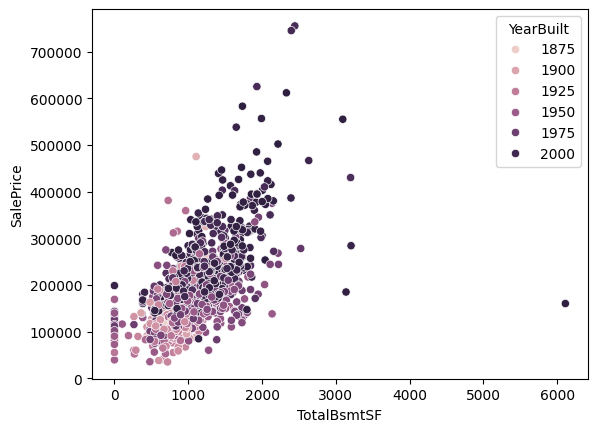

In [32]:
sns.scatterplot(data=df, x="TotalBsmtSF", y="SalePrice", hue="YearBuilt")
plt.show()

In [33]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [34]:
df.drop(["Id"], axis=1, inplace=True)

In [35]:
# Replacing SalePrice empty values with their mean values
df["SalePrice"] = df["SalePrice"].fillna(df["SalePrice"].mean())

In [36]:
df = df.dropna()

In [37]:
df.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [38]:
# Data Preprocessing - Encoding (Covered in Supervised ML Part2)
cols = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
df = pd.get_dummies(df, columns=cols, drop_first=True)

In [39]:
# Train-Test Split
X = df.drop(['SalePrice'], axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [40]:
X_train.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
2356,20,7441,5,2006,2006,0.0,1461.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1789,30,10800,5,1890,1998,0.0,630.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2371,20,7321,5,1999,2000,0.0,1339.0,True,False,False,...,True,False,False,False,False,False,False,False,False,False
930,20,8925,5,2007,2007,0.0,1466.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2816,20,13050,6,1963,1963,850.0,1000.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [41]:
X_train.dtypes

MSSubClass               int64
LotArea                  int64
OverallCond              int64
YearBuilt                int64
YearRemodAdd             int64
BsmtFinSF2             float64
TotalBsmtSF            float64
MSZoning_FV               bool
MSZoning_RH               bool
MSZoning_RL               bool
MSZoning_RM               bool
LotConfig_CulDSac         bool
LotConfig_FR2             bool
LotConfig_FR3             bool
LotConfig_Inside          bool
BldgType_2fmCon           bool
BldgType_Duplex           bool
BldgType_Twnhs            bool
BldgType_TwnhsE           bool
Exterior1st_AsphShn       bool
Exterior1st_BrkComm       bool
Exterior1st_BrkFace       bool
Exterior1st_CBlock        bool
Exterior1st_CemntBd       bool
Exterior1st_HdBoard       bool
Exterior1st_ImStucc       bool
Exterior1st_MetalSd       bool
Exterior1st_Plywood       bool
Exterior1st_Stone         bool
Exterior1st_Stucco        bool
Exterior1st_VinylSd       bool
Exterior1st_Wd Sdng       bool
Exterior

In [42]:
# Model Train
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
# Using model to predict values
y_pred = model.predict(X_test)

In [46]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.3469223785187573
MAE: 32690.891525374318
RMSE: 48797.194708473966
